# NTEMS

## Download Data

In [ ]:
import wget
import os
import zipfile


def download_and_unzip(url, output_directory):
    filename = wget.download(url, out=output_directory)
    print(f"\nDownload complete. File saved as: {filename}")
    # Unzip the file
    zip_file_path = os.path.join(output_directory, f"CA_Tree_Species_Classification_{year}.zip")
    with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        zip_ref.extractall(output_directory)
    print(f"Files extracted successfully to: {output_directory}")

prefix = "https://opendata.nfis.org/downloads/forest_change"
urls = [
    f"{prefix}/CA_forest_harvest_mask_year_1985_2015.zip",
    f"{prefix}/CA_forest_wildfire_year_DNBR_Magnitude_1985_2015.zip",
]
years = ["2018", "2019", "2020", "2021", "2022"]
for year in years:
    urls.append(f"{prefix}/CA_Tree_Species_Classification_{year}.zip")

output_directory = "/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems"
os.makedirs(output_directory, exist_ok=True)  # Create directory if it doesn't exist
for url in urls:
    download_and_unzip(url, output_directory)

## Generate Disturbance Dataset

In [ ]:
import glob
from os.path import join
import geopandas
import rasterio
from image_utils import clip_raster, merge_rasters

directory=r'/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON/disturb'
boundary = r"/mnt/d/Sync/research/tree_species_estimation/tree_dataset/data_processing/FORMGMT/LIO-2023-08-19/FOREST_MANAGEMENT_UNIT.shp"
fire_1985_2020 = r'/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/CA_Forest_Fire_1985-2020.tif'
harvest_1985_2020 = r'/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/CA_Forest_Harvest_1985-2020.tif'

with rasterio.open(fire_1985_2020) as src:
    out_crs = src.crs

gdf = geopandas.read_file(boundary).to_crs(out_crs)
reproject_boundary = r"/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON/ROI_ON_ntems.shp"
gdf.to_file(reproject_boundary)

clip_raster(
    fire_1985_2020,
    reproject_boundary,
    join(directory, "on_forest_fire_1985_2020_clipped.tif"),
)
clip_raster(
    harvest_1985_2020,
    reproject_boundary,
    join(directory, "on_forest_harvest_1985_2020_clipped.tif"),
)

# merge rasters from disturbances of different years
directory = r"/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON"
input_files = glob.glob(join(directory, "disturb", "*.tif"))
output_file = join(directory, "disturb", "on_ntems_merged_1985_2020.tif")
merge_rasters(input_files, output_file, method="max")

In [ ]:
# merge disturbances 1985-2020

# Open the raster file
with rasterio.open(
    r"/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON/disturb/on_ntems_merged_1985_2020.tif"
) as src:
    # Read the data into an array
    raster_data = src.read(1)  # Assuming the data is in the first band

    # Replace values 1985 to 2020 with 1 (indicating change)
    change_mask = (raster_data >= 1985) & (raster_data <= 2020)
    raster_data[change_mask] = 1

    # Define new metadata for the output file
    new_meta = src.meta.copy()

# Save the modified raster
with rasterio.open(
    r"/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON/disturb/on_ntems_merged_years.tif",
    "w",
    **new_meta
) as dst:
    dst.write(raster_data, 1)

## Mask Disturbance

In [ ]:

import os
from os.path import join
from image_utils import ntems_mask

directory = r"/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON"
mask_file = join(directory, "disturb", "on_ntems_merged_years.tif")
boundary = os.path.join(directory, "ROI_ON_ntems.gpkg")
# Data codes: 0 = no change, 1 = wildfire, 2 = harvest,
# 5 = lower confidence wildfire, 6 = lower confidence harvest
mask_values = [1]
years = ["2018", "2019", "2020", "2021", "2022"]
for year in years:
    ntems_mask(
        f"/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON/ON_Tree_Species_Classification_{year}.tif",
        mask_file,
        mask_values,
        join(directory, f"ON_Tree_Species_Classification_{year}_ntems.tif"),
    )

## Generate Grids

Generate the Stable Species Mask

In [6]:
import rasterio
import numpy as np
import os

def create_stable_mask(ntems_paths, output_mask_path):
    """
    Creates a single .tif where a pixel has a value ONLY if it was
    identical across all input years and not 0 or 34.
    """
    srcs = [rasterio.open(p) for p in ntems_paths]
    meta = srcs[0].meta.copy()
    meta.update(
        dtype="uint8", nodata=0, compress="lzw"
    )  # Use compression to save disk space

    with rasterio.open(output_mask_path, "w", **meta) as dst:
        # Loop through the raster in blocks (e.g., 256x256 or 512x512)
        for _, window in srcs[0].block_windows():
            # Read all years for this block
            stack = np.array([src.read(1, window=window) for src in srcs])

            # Identify pixels where:
            # 1. All years are equal
            # 2. Value is not 0 (non-treed)
            # 3. Value is not 34 (Hemlock)
            stable_mask = (
                np.all(stack == stack[0], axis=0) & (stack[0] != 0) & (stack[0] != 34)
            )

            # Create output: stable species ID if True, else 0
            out_block = np.where(stable_mask, stack[0], 0).astype("uint8")

            dst.write(out_block, window=window, indexes=1)

    for src in srcs:
        src.close()
    print(f"Stable Mask saved to {output_mask_path}")


folder = "/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON"
years = ["2018", "2019", "2020", "2021", "2022"]
ntems_files = []

for year in years:
    ntems_files.append(
        os.path.join(folder, f"ON_Tree_Species_Classification_{year}_ntems.tif")
    )
create_stable_mask(ntems_files, os.path.join(folder, "Ontario_Stable_Mask.tif"))

Stable Mask saved to /mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON/Ontario_Stable_Mask.tif


In [18]:
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd


def sampled_stable_coords_distributed(mask_path, tempfile, cap=10000, seed=42):
    np.random.seed(seed)

    # Define your specific 15 target species IDs (based on your table)
    valid_species = [2, 5, 6, 9, 10, 12, 13, 17, 18, 22, 25, 26, 28, 29, 31, 32]
    print("Step 1: Counting species distribution (Filtering 255/NoData)...")
    with rasterio.open(mask_path) as src:
        data = src.read(1)
        # Only count if value is in our target list
        mask = np.isin(data, valid_species)
        unique, counts = np.unique(data[mask], return_counts=True)
        stats = dict(zip(unique, counts))

    # Calculate probabilities with a safety buffer
    probs = {sid: min(1.0, (cap * 1.3) / count) for sid, count in stats.items()}
    species_coords = {sid: [] for sid in stats.keys()}

    print("Step 2: Geographically distributed sampling...")
    with rasterio.open(mask_path) as src:
        # Process in blocks to save RAM
        for _, window in src.block_windows():
            block = src.read(1, window=window)

            # Mask block for only valid species (ignores 0, 34, 255)
            rows, cols = np.where(np.isin(block, valid_species))

            for r, c in zip(rows, cols):
                sid = block[r, c]

                # Check if this species still needs samples
                if len(species_coords[sid]) < cap:
                    # Probabilistic skip for geographical spread
                    if np.random.random() < probs[sid]:
                        # FIXED: Use 'c' for column index
                        x, y = rasterio.transform.xy(
                            src.transform,
                            r + window.row_off,
                            c + window.col_off,
                            offset="center",
                        )
                        species_coords[sid].append({"x": x, "y": y, "label": int(sid)})

    # Flatten and final trim
    all_records = [item for sublist in species_coords.values() for item in sublist]
    df = pd.DataFrame(all_records)

    # Final trim to exactly the cap
    df = df.groupby("label").head(cap).reset_index(drop=True)

    print("\n--- Final Balanced Sample Counts ---")
    print(df["label"].value_counts().sort_index())
    df.to_csv(tempfile)

In [19]:
def finalize_pretrain_plan(tempcsv, spl_index_shp, ecoregion_shp, output_gpkg):
    df_coords = pd.read_csv(tempcsv)
    print(f"samples input: {len(df_coords)} plots.")
    # Convert points to GeoDataFrame (NTEMS is 3978)
    gdf = gpd.GeoDataFrame(
        df_coords, geometry=gpd.points_from_xy(df_coords.x, df_coords.y), crs=3978
    )

    # 1. Join with Ecoregions
    ecoregions = gpd.read_file(ecoregion_shp).to_crs(3978)
    gdf = gpd.sjoin(
        gdf, ecoregions[["SITE_REG_O", "geometry"]], how="inner", predicate="within"
    )

    # 2. Join with SPL Index
    spl_index = gpd.read_file(spl_index_shp).to_crs(3978)
    # This identifies the 1km tile each plot belongs to
    final_gdf = gpd.sjoin(
        gdf,
        spl_index[["Tilename", "Download_H", "geometry"]],
        how="inner",
        predicate="within",
        rsuffix="_spl",
    )

    # 3. Save to GPKG
    final_gdf.to_file(output_gpkg, driver="GPKG", layer="sampling_plan_10k")
    print(f"Final sampling plan created: {len(final_gdf)} plots.")

In [20]:
aux_folder = "/mnt/d/Sync/research/tree_species_estimation/tree_dataset"
spl_index_path = os.path.join(aux_folder, "data_processing", "FRI_Leaf_On_Tile_Index_SHP", "FRI_Tile_Index.shp")
ecoregion_path = os.path.join(aux_folder, "mapping", "Mapping", "EcoRegion", "Site_Region_.shp")
tempcsv = os.path.join(folder, "ON_Pretrain_SPL_cap10k_temp.csv")
output_gpkg = os.path.join(folder, "ON_Pretrain_SPL_cap10k.gpkg")

sampled_stable_coords_distributed(os.path.join(folder, "Ontario_Stable_Mask.tif"), tempcsv)
finalize_pretrain_plan(tempcsv, spl_index_path, ecoregion_path, output_gpkg)

Step 1: Counting species distribution (Filtering 255/NoData)...
Step 2: Geographically distributed sampling...

--- Final Balanced Sample Counts ---
label
2     10000
5     10000
6     10000
9        78
10    10000
12    10000
13     1466
17     8634
18    10000
22    10000
25    10000
26    10000
28     8323
29    10000
31    10000
32    10000
Name: count, dtype: int64
samples input: 138501 plots.
Final sampling plan created: 126581 plots.


# download dataset

In [ ]:
import subprocess
import os
from pathlib import Path

# --- TEST SETTINGS ---
# Use a real URL from your GPKG here
test_url = "https://download.fri.mnrf.gov.on.ca/api/api/Download/hag/utm18/1kmZ183260504102022L_HAG.copc.laz"
# ---------------------


def test_download():
    # 1. Determine local path
    # We use current directory '.' for this local test
    filename = test_url.split("/")[-1]
    local_path = Path(".").resolve() / filename

    print(f"Targeting download to: {local_path}")

    # 2. Try Download
    # Remove -q so we can see the errors!
    cmd = ["wget", "-O", str(local_path), test_url]
    print(f"Running command: {' '.join(cmd)}")

    result = subprocess.run(cmd, capture_output=True, text=True)

    if local_path.exists():
        print(f"✅ SUCCESS: File exists at {local_path}")
        print(f"📏 SIZE: {local_path.stat().st_size / 1e6:.2f} MB")
    else:
        print(f"❌ FAILED: File does not exist.")
        print(f"STDOUT: {result.stdout}")
        print(f"STDERR: {result.stderr}")


if __name__ == "__main__":
    test_download()

Targeting download to: /mnt/d/Sync/research/tree_species_estimation/code/CE-TSC/data_processing/1kmZ183260504102022L_HAG.copc.laz
Running command: wget -O /mnt/d/Sync/research/tree_species_estimation/code/CE-TSC/data_processing/1kmZ183260504102022L_HAG.copc.laz https://download.fri.mnrf.gov.on.ca/api/api/Download/hag/utm18/1kmZ183260504102022L_HAG.copc.laz
✅ SUCCESS: File exists at /mnt/d/Sync/research/tree_species_estimation/code/CE-TSC/data_processing/1kmZ183260504102022L_HAG.copc.laz
📏 SIZE: 314.03 MB


In [12]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pdal
from pathlib import Path
from pyproj import Transformer
import re

def get_native_epsg(laz_path):
    """Detects EPSG code from LAZ/COPC metadata. Handles both dict/str returns."""
    try:
        pipeline = pdal.Pipeline(json.dumps([
            {"type": "readers.las", "filename": str(laz_path), "count": 1}
        ]))
        pipeline.execute()
        meta = pipeline.metadata
        if isinstance(meta, str):
            meta = json.loads(meta)
            
        srs = meta['metadata']['readers.las']['srs']['compoundwkt']
        match = re.search(r'EPSG",(\d+)', srs)
        return f"EPSG:{match.group(1)}" if match else "EPSG:2959"
    except Exception as e:
        return "EPSG:2959"
    
def debug_local_processing(laz_path, gpkg_path, tile_name_to_test):
    print(f"--- Diagnostic: {tile_name_to_test} ---")
    
    # 1. Load GPKG and find the test plot
    gdf = gpd.read_file(gpkg_path, layer="sampling_plan_10k")
    tile_plots = gdf[gdf["Tilename"] == tile_name_to_test]
    
    if len(tile_plots) == 0:
        print("❌ Error: No plots found in GPKG for this tile name.")
        return

    # 2. Setup the Bridge: Canada Lambert (3978) -> UTM 18N (2959)
    # This turns your 1,392,344 into 326,000
    native_epsg = get_native_epsg(laz_path)
    transformer = Transformer.from_crs("EPSG:3978", native_epsg, always_xy=True)

    row = tile_plots.iloc[0]
    cx_3978, cy_3978 = row["x"], row["y"]
    cx_tile, cy_tile = transformer.transform(cx_3978, cy_3978)

    print(f"Coordinates:")
    print(f"  Input (Lambert): {cx_3978:.2f}, {cy_3978:.2f}")
    print(f"  Target (UTM 18N): {cx_tile:.2f}, {cy_tile:.2f}")

    # 3. PDAL Pipeline
    p_json = [
        {"type": "readers.las", "filename": str(laz_path)},
        {"type": "filters.crop", "point": f"POINT({cx_tile} {cy_tile})", "distance": 15},
        {"type": "filters.range", "limits": "Z(2:)"}
    ]

    try:
        pipe = pdal.Pipeline(json.dumps(p_json))
        pipe.execute()
        
        # FIX: Check if arrays exist before indexing
        if not pipe.arrays:
            print("❌ FAILED: PDAL found 0 points. Checking file bounds...")
            # Let's see what the file actually contains
            meta_pipe = pdal.Pipeline(json.dumps([{"type":"readers.las", "filename":str(laz_path)}, {"type":"filters.stats"}]))
            meta_pipe.execute()
            # Handle potential dict/str metadata return
            meta = meta_pipe.metadata
            if isinstance(meta, str): meta = json.loads(meta)
            bounds = meta['metadata']['readers.las']
            print(f"  File Bounds: X[{bounds['minx']}:{bounds['maxx']}]")
            return

        pts = pipe.arrays[0]
        print(f"✅ SUCCESS! Found {len(pts)} points above 2m.")
        print(f"  Sample Z values: {pts['Z'][:5]}")

    except Exception as e:
        print(f"❌ ERROR: {e}")

In [14]:
gdf = gpd.read_file("D:\\Sync\\research\\tree_species_estimation\\tree_dataset\\ntems\\ON\\ON_Pretrain_SPL_cap10k.gpkg", layer="sampling_plan_10k")
gdf.crs

<Projected CRS: EPSG:3978>
Name: NAD83 / Canada Atlas Lambert
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Canada - onshore and offshore - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon.
- bounds: (-141.01, 38.21, -40.73, 86.46)
Coordinate Operation:
- name: Canada Atlas Lambert
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [13]:
# HOW TO RUN:
debug_local_processing(
    "D:\\Sync\\research\\tree_species_estimation\\tree_dataset\\ntems\\ON\\1kmZ183260504102022L_HAG.copc.laz",
    "D:\\Sync\\research\\tree_species_estimation\\tree_dataset\\ntems\\ON\\ON_Pretrain_SPL_cap10k.gpkg",
    "1kmZ183260504102022L",
)

--- Diagnostic: 1kmZ183260504102022L ---
Coordinates:
  Input (Lambert): 1392344.48, -195026.89
  Target (UTM 18N): 326953.46, 5041854.18
✅ SUCCESS! Found 25730 points above 2m.
  Sample Z values: [3.29 3.31 2.7  8.41 8.89]


In [5]:
import geopandas as gpd

gdf = gpd.read_file(
    "/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON/ON_Pretrain_SPL_cap10k.gpkg",
    layer="sampling_plan_10k",
)

In [6]:
tile_df = gdf[gdf["Tilename"] == "1kmZ163970557702023L"]
tile_df.head()

,Unnamed: 0,x,y,label,index_right,SITE_REG_O,index__spl,Tilename,Download_H,geometry
0,0,464174.476,172833.1105,2,8,3W,115025,1kmZ163970557702023L,https://download.fri.mnrf.gov.on.ca/api/api/Do...,POINT (464174.476 172833.11)
1,1,464204.476,172803.1105,2,8,3W,115025,1kmZ163970557702023L,https://download.fri.mnrf.gov.on.ca/api/api/Do...,POINT (464204.476 172803.11)
100225,109265,463574.476,172203.1105,29,8,3W,115025,1kmZ163970557702023L,https://download.fri.mnrf.gov.on.ca/api/api/Do...,POINT (463574.476 172203.11)


In [8]:
records = []
for _, r in tile_df.iterrows():
    records.append(
        {
            "label": int(r["label"]),
            "ecoregion": str(r.get("SITE_REG_O", 0)),
        }
    )
records

[{'label': 2, 'ecoregion': '3W'},
 {'label': 2, 'ecoregion': '3W'},
 {'label': 29, 'ecoregion': '3W'}]

# Dataset splitting - Tile-Level Stratification

In [2]:
import pandas as pd
import glob
import numpy as np
from sklearn.model_selection import train_test_split

# Load Master List
all_files = "/mnt/g/on_ntems/training_master_list.csv"
df = pd.read_csv(all_files)

# 1. Tile-Level Metadata for Stratification
tile_metadata = (
    df.groupby("tilename")
    .agg(
        {
            "label": lambda x: x.value_counts().index[0],
            "ecoregion": lambda x: x.value_counts().index[0],
        }
    )
    .reset_index()
)

tile_metadata["stratify_key"] = (
    tile_metadata["label"].astype(str) + "_" + tile_metadata["ecoregion"].astype(str)
)

# --- FIX: HANDLE SINGLETON CLASSES ---
counts = tile_metadata["stratify_key"].value_counts()
singletons = counts[counts < 2].index

if len(singletons) > 0:
    print(
        f"Found {len(singletons)} unique species/ecoregion tiles. Reassigning to 'other' for splitting..."
    )
    # Map any key that appears only once to a generic 'other' category
    tile_metadata["stratify_key_safe"] = tile_metadata["stratify_key"].apply(
        lambda x: "other" if x in singletons else x
    )
else:
    tile_metadata["stratify_key_safe"] = tile_metadata["stratify_key"]

# 2. First Split: Separate Test set (15%)
# Use 'stratify_key_safe' to ensure classes have at least 2 members
train_val_tiles, test_tiles = train_test_split(
    tile_metadata,
    test_size=0.15,
    stratify=tile_metadata["stratify_key_safe"],
    random_state=42,
)

# 3. Second Split: Separate Train and Val (0.15 / 0.85 = 0.17647)
# Recalculate safe keys for the sub-split in case new singletons were created
counts_sub = train_val_tiles["stratify_key_safe"].value_counts()
singletons_sub = counts_sub[counts_sub < 2].index
train_val_tiles["stratify_key_safe"] = train_val_tiles["stratify_key_safe"].apply(
    lambda x: "other_sub" if x in singletons_sub else x
)

train_tiles, val_tiles = train_test_split(
    train_val_tiles,
    test_size=0.17647,
    stratify=train_val_tiles["stratify_key_safe"],
    random_state=42,
)

# 4. Map Tile IDs back to the original Plot-Level Dataframe
train_df = df[df["tilename"].isin(train_tiles["tilename"])]
val_df = df[df["tilename"].isin(val_tiles["tilename"])]
test_df = df[df["tilename"].isin(test_tiles["tilename"])]

# 5. Save static CSVs
train_df.to_csv("/mnt/g/on_ntems/train_split.csv", index=False)
val_df.to_csv("/mnt/g/on_ntems/val_split.csv", index=False)
test_df.to_csv("/mnt/g/on_ntems/test_split.csv", index=False)

print("--- 70/15/15 Tile-Level Split Complete ---")
print(f"Total Plots: {len(df)}")
print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df):.1%})")

Found 4 unique species/ecoregion tiles. Reassigning to 'other' for splitting...
--- 70/15/15 Tile-Level Split Complete ---
Total Plots: 91533
Train: 63373 (69.2%)
Val:   14375 (15.7%)
Test:  13785 (15.1%)


# pipeline figure

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def create_journal_workflow_v2():
    fig, ax = plt.subplots(figsize=(12, 9), dpi=300)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Styles
    box_s = "round,pad=0.2"
    colors = {"data": "#e1f5fe", "proc": "#ffffff", "label": "#fff3e0", "model": "#e8f5e9"}
    
    # --- 3.1 DATA SOURCES ---
    ax.text(6, 9.7, "PROVINCIAL DATASET GENERATION ARCHITECTURE", ha='center', weight='bold', fontsize=14)
    
    # Boxes for 3.1
    ax.add_patch(FancyBboxPatch((0.5, 8.2), 3.3, 1.0, boxstyle=box_s, fc=colors["data"], ec="#0288d1"))
    ax.text(2.15, 8.7, "3.1.1 LiDAR (SPL)\nPoint Clouds (HAG)", ha='center', fontsize=10, weight='bold')
    
    ax.add_patch(FancyBboxPatch((4.3, 8.2), 3.3, 1.0, boxstyle=box_s, fc=colors["data"], ec="#0288d1"))
    ax.text(5.95, 8.7, "3.1.2 NTEMS (30m)\nSpecies & Disturbance", ha='center', fontsize=10, weight='bold')

    ax.add_patch(FancyBboxPatch((8.1, 8.2), 3.3, 1.0, boxstyle=box_s, fc=colors["data"], ec="#0288d1"))
    ax.text(9.75, 8.7, "3.1.3 Environmental\nEcoregion Context", ha='center', fontsize=10, weight='bold')

    # --- 3.2 PROCESSING & SAMPLING ---
    proc_rect = FancyBboxPatch((0.5, 4.2), 11, 3.5, boxstyle=box_s, fc=colors["proc"], ec="#37474f", lw=1.5)
    ax.add_patch(proc_rect)
    ax.text(1, 7.4, "3.2 SPATIALLY-STRATIFIED DATASET SYNTHESIS", weight='bold', color="#37474f")
    
    ax.text(0.8, 6.8, "• Temporal Stability Check (2018-2022)\n• Species Filtering (Excl. E. Hemlock)\n• Disturbance Masking", fontsize=10)
    ax.text(6.0, 6.8, "• 1km Systematic Stratified Grid\n• N = 126,581 Provincial Plots\n• Circular Clipping (Radius=11.28m)", fontsize=10)
    ax.text(0.8, 5.0, "• Height Normalization & Filtering (>2m)\n• Fixed Cardinality Sampling (N=8,192)", fontsize=10, style='italic')

    # --- 3.3 LABEL GENERATION ---
    ax.add_patch(FancyBboxPatch((0.5, 1.5), 11, 2.2, boxstyle=box_s, fc=colors["label"], ec="#ef6c00", lw=1.5))
    ax.text(1, 3.3, "3.3 ATTRIBUTE EXTRACTION (MULTI-TASK LABELS)", weight='bold', color="#ef6c00")
    
    tasks = [
        ("TAXONOMIC (Weak)", "NTEMS Leading Species Class"),
        ("STRUCTURAL (Strong)", "LiDAR Proxies: H95, Canopy Cover"),
        ("CONTEXTUAL (Spatial)", "Provincial Ecoregion ID")
    ]
    for i, (t, d) in enumerate(tasks):
        ax.text(1.5 + i*3.5, 2.6, t, ha='center', weight='bold', fontsize=9)
        ax.text(1.5 + i*3.5, 2.2, d, ha='center', fontsize=8)

    # --- 3.4 DATASET SPLIT ---
    ax.add_patch(FancyBboxPatch((4.5, 0.2), 3, 0.8, boxstyle=box_s, fc="#cfd8dc", ec="#263238"))
    ax.text(6, 0.5, "3.4 DATASET SPLIT\nTile-level (80/10/10)", ha='center', weight='bold', fontsize=10)

    # Arrows
    arrow_props = dict(arrowstyle='->', lw=1.5, color="#263238")
    for x in [2.15, 5.95, 9.75]:
        ax.annotate('', xy=(x, 7.7), xytext=(x, 8.2), arrowprops=arrow_props)
    ax.annotate('', xy=(6, 3.7), xytext=(6, 4.2), arrowprops=arrow_props)
    ax.annotate('', xy=(6, 1.0), xytext=(6, 1.5), arrowprops=arrow_props)

    plt.savefig("fig1_methodology.png", bbox_inches='tight')
    plt.show()


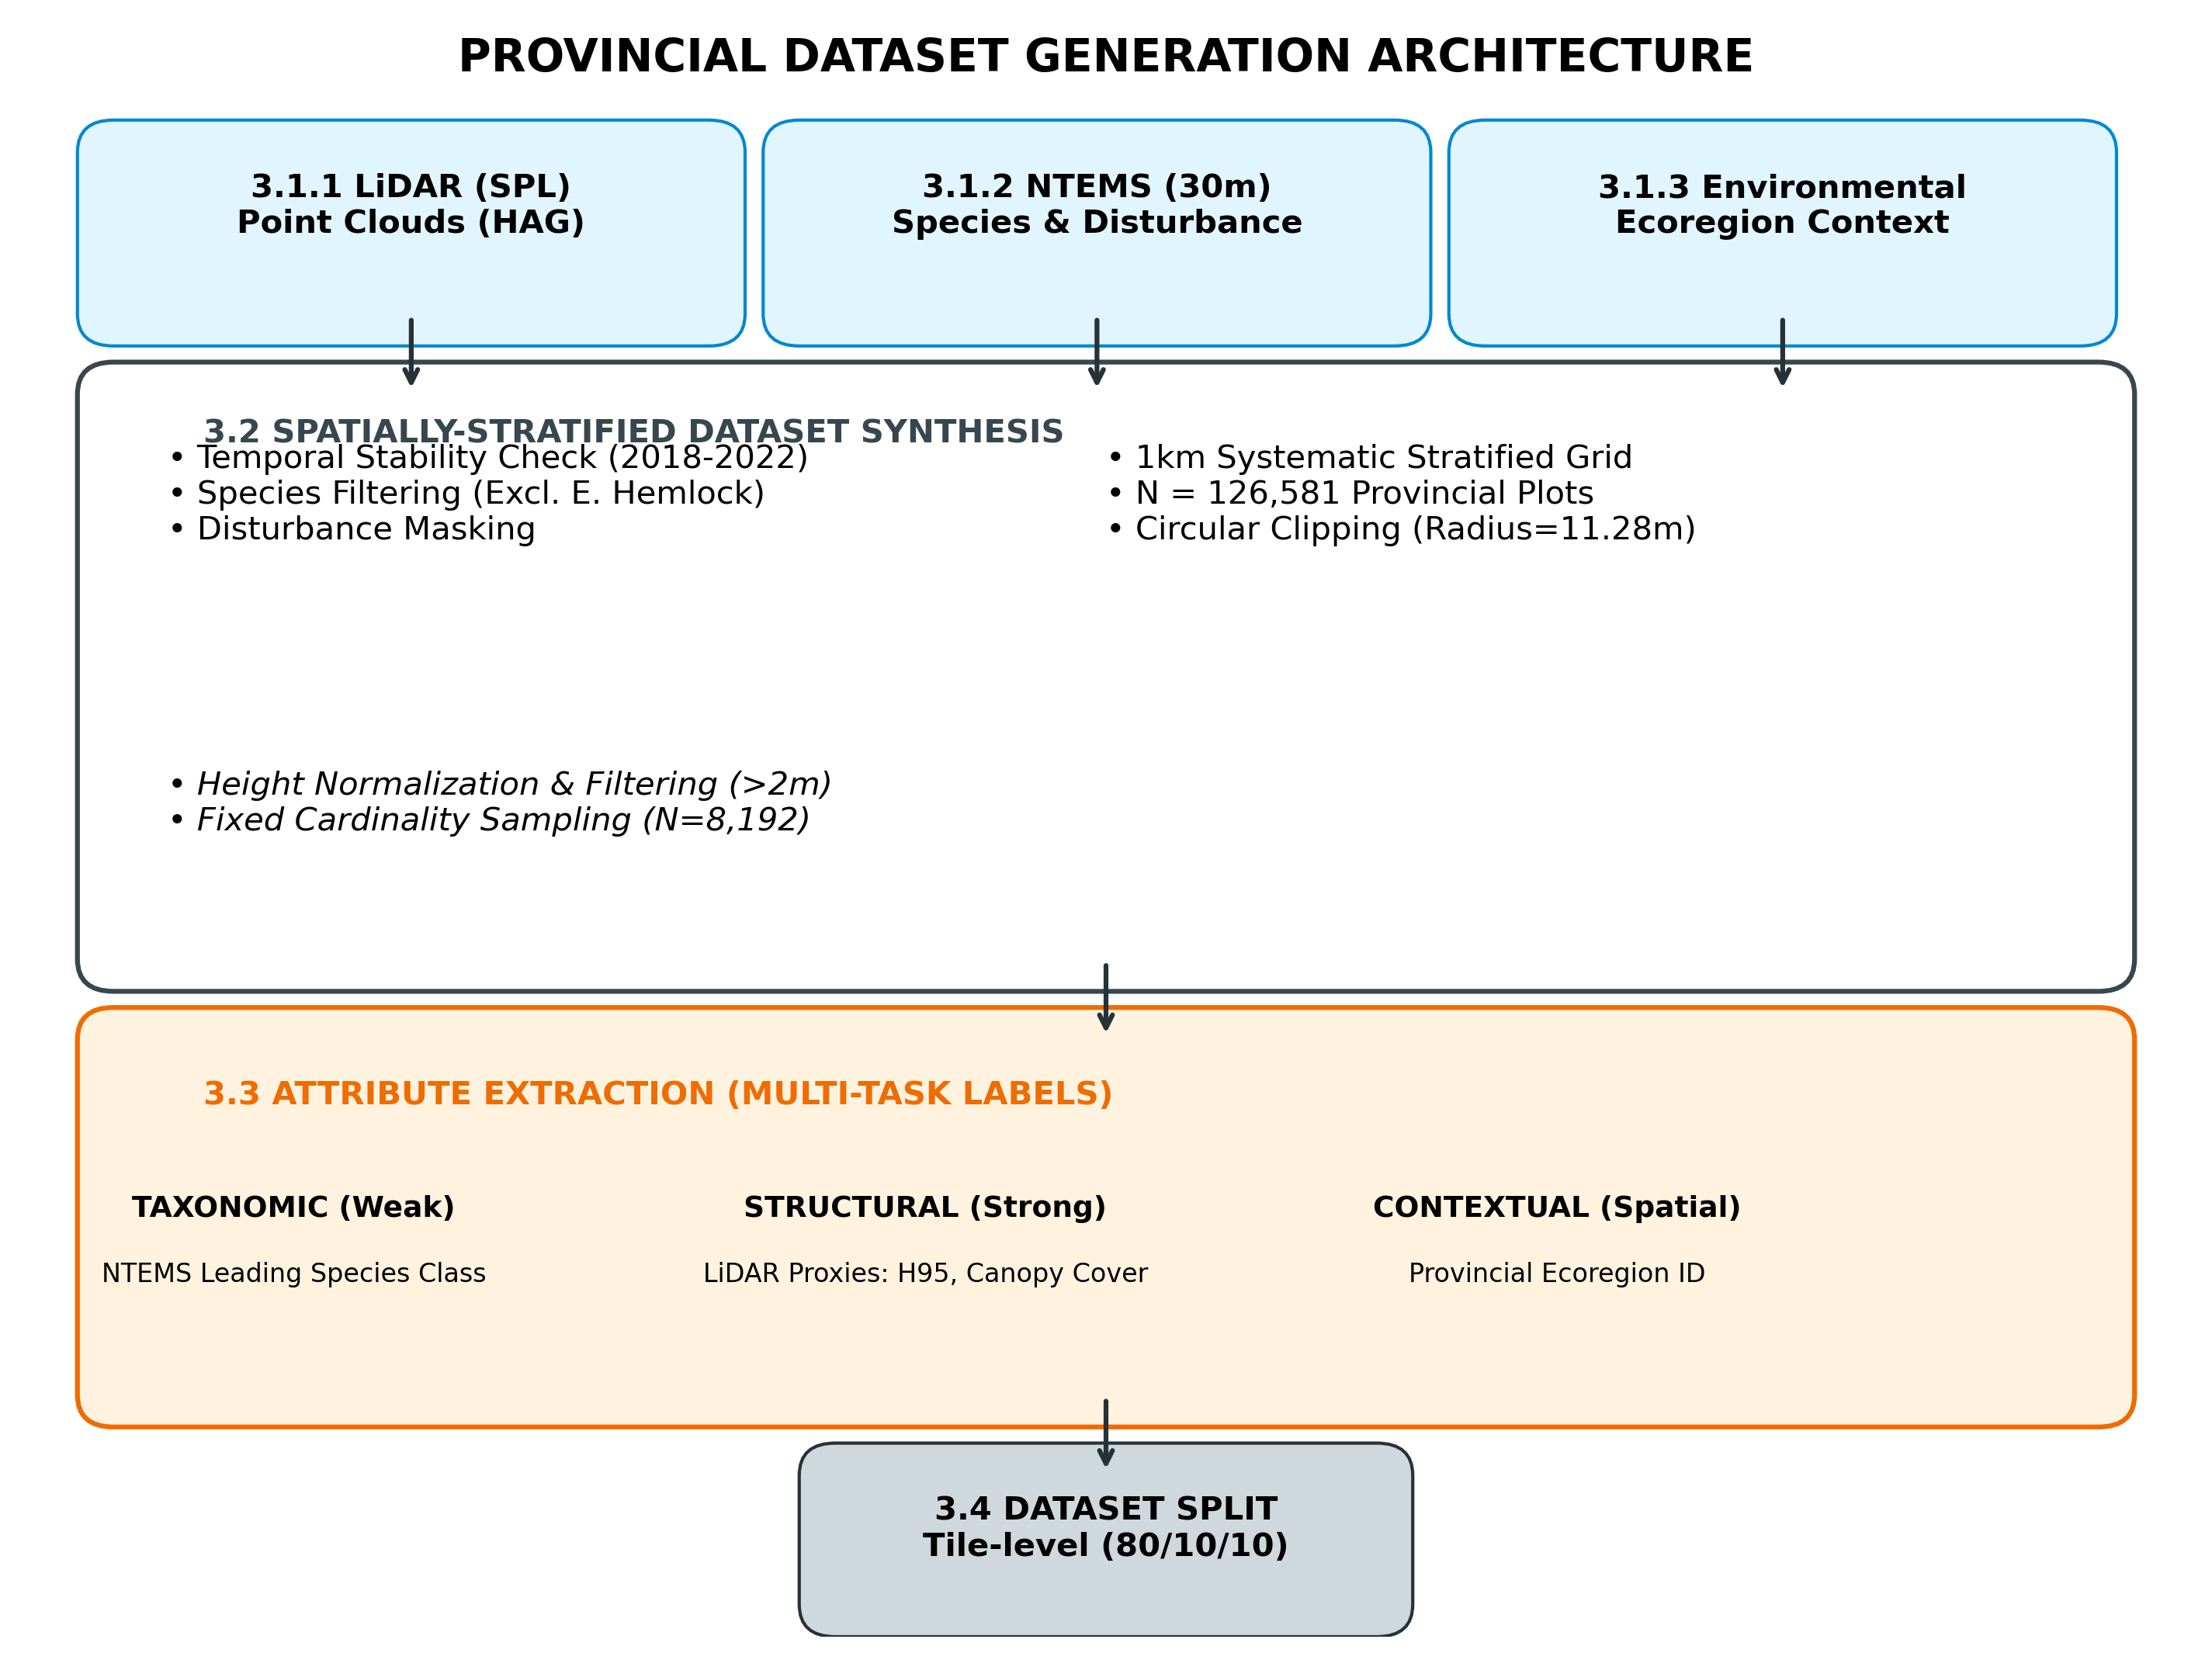

In [2]:
create_journal_workflow_v2()

calculate class weights

In [1]:
import pandas as pd
import numpy as np

# Load CSV
all_files = "/mnt/g/on_ntems/training_master_list.csv"
df = pd.read_csv(all_files)

# Get label counts
class_counts = df["label"].value_counts().sort_index()

# Convert to numpy
class_counts_np = class_counts.to_numpy(dtype=float)

# Inverse frequency weights
epsilon = 1e-8
class_weights = 1.0 / (class_counts_np + epsilon)

# Normalize so weights sum to number of classes
class_weights = class_weights / class_weights.sum() * len(class_weights)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
label
2     9788
5     8763
6     8327
9       78
10    7725
12    1640
13     235
17    1890
18    4674
22    6926
25    8049
26    9326
28    8068
29    7139
31    4117
32    4788
Name: count, dtype: int64

Class weights:
[ 0.08178964  0.0913565   0.09613991 10.26355174  0.10363198  0.48814453
  3.40662568  0.42357515  0.17127878  0.11558721  0.09946043  0.08584141
  0.09922621  0.11213854  0.19445155  0.16720072]


In [3]:
np.array(class_weights)

array([ 0.08178964,  0.0913565 ,  0.09613991, 10.26355174,  0.10363198,
        0.48814453,  3.40662568,  0.42357515,  0.17127878,  0.11558721,
        0.09946043,  0.08584141,  0.09922621,  0.11213854,  0.19445155,
        0.16720072])

In [3]:
import numpy as np
import os
from ast import literal_eval

# Path to the "train" folder


# Initialize a list to store all plot_label data
all_labels = []
dataset = "wrf"
level = "sp"


def avg_plot_entropy(labels):
    eps = 1e-8
    ent = -np.sum(labels * np.log(labels + eps), axis=1)
    return ent.mean(), ent.std()


# Iterate through all files in the "train" folder
for split in ["train"]:
    train_folder = f"/mnt/g/{dataset}/{dataset}_superpixel_dataset/tile_128/{split}/{dataset}_{level}"
    for filename in os.listdir(train_folder):
        if filename.endswith(".npz"):
            file_path = os.path.join(train_folder, filename)
            data = np.load(file_path)
            label = np.array(data["label"], dtype=float)  # Shape: (num_classes,)
            all_labels.append(label)

# Convert the list of labels to a NumPy array
all_labels = np.array(all_labels)  # Shape: (num_samples, num_classes)
print(avg_plot_entropy(all_labels))

(np.float64(0.851183777619532), np.float64(0.3115400346585383))


Does Ovf dataset have more mixed-species plots? (Higher composition entropy)

ovf: (np.float64(0.7741365748671571), np.float64(0.5969187214312726))

nif: (np.float64(0.6478664193155386), np.float64(0.32154843017963947))

wrf: (np.float64(0.851183777619532), np.float64(0.3115400346585383))

# Geotessera embeddings

## Downloading (activate conda base)

In [ ]:
!geotessera download --region-file /mnt/d/Sync/research/tree_species_estimation/tree_dataset/data_processing/FORMGMT/ROI_WRF/ROI_WRF.shp --format npy --year 2024 --output /mnt/e/wrf_img/tessera_tiles

tiff: 

Name	EPSG:32618 - WGS 84 / UTM zone 18N

Units	meters

Type	Projected

Method	Universal Transverse Mercator (UTM)

Celestial Body	Earth

Accuracy	Based on World Geodetic System 1984 ensemble (EPSG:6326), which has a limited accuracy of at best 2 meters.

Reference	Dynamic (relies on a datum which is not plate-fixed)

## sampling plots embeddings

In [ ]:
import geopandas as gpd
import numpy as np
import rasterio
import glob
import os
from shapely.geometry import box
from tqdm import tqdm

# SETTINGS
DATASET='rmf'
PATCH_SIZE = 3  # This will create a 3x3 pixel grid
output_dir = f"/mnt/e/{DATASET}_img/tessera_tiles/{DATASET}_embeddings"
os.makedirs(output_dir, exist_ok=True)

# Load plots - Keep in original CRS for now
plots_raw = gpd.read_file(
    f"/mnt/d/Sync/research/tree_species_estimation/tree_dataset/{DATASET}/{DATASET}_plots/fusion/superpixel_plots_20m_Tilename.gpkg"
)
#plots_raw = gpd.read_file(f"/mnt/d/Sync/research/tree_species_estimation/tree_dataset/{DATASET}/processed/{DATASET}_plots/superpixel_plots_Tilename.gpkg")
# Ensure POLYID is the index for easy lookup
plots_raw = plots_raw.set_index("POLYID")

tiff_dir = "/mnt/e/nif_img/tessera_tiles/global_0.1_degree_tiff_all"
repr_dir = "/mnt/e/nif_img/tessera_tiles/global_0.1_degree_representation/2024"

tiff_files = glob.glob(os.path.join(tiff_dir, "*.tiff"))

for tiff_path in tqdm(tiff_files):
    base_name = os.path.basename(tiff_path).replace(".tiff", "")

    with rasterio.open(tiff_path) as src:
        tile_crs = src.crs
        tile_transform = src.transform
        tile_bounds = src.bounds  # (left, bottom, right, top) in UTM meters

    # 1. Project plots to THIS tile's specific CRS
    # This handles tiles that might be in different UTM zones
    plots_projected = plots_raw.to_crs(tile_crs)

    # 2. Find plots that fall inside this specific tile's UTM box
    tile_box = box(*tile_bounds)
    intersecting_plots = plots_projected[plots_projected.intersects(tile_box)].copy()

    if intersecting_plots.empty:
        continue

    # Load the big representation data
    grid_folder = os.path.join(repr_dir, base_name)
    q_emb_path = os.path.join(grid_folder, f"{base_name}.npy")
    scales_path = os.path.join(grid_folder, f"{base_name}_scales.npy")

    if not os.path.exists(q_emb_path):
        continue

    q_emb = np.load(q_emb_path)  # (H, W, Dim)
    scales = np.load(scales_path)  # (H, W)

    half_patch = PATCH_SIZE // 2

    for polyid, plot in intersecting_plots.iterrows():
        # Get pixel center
        cx, cy = plot.geometry.centroid.x, plot.geometry.centroid.y
        px, py = ~tile_transform * (cx, cy)
        px, py = int(px), int(py)

        # Define fixed window
        r_start, r_end = py - half_patch, py + half_patch + 1
        c_start, c_end = px - half_patch, px + half_patch + 1

        # Boundary safety check
        if r_start < 0 or r_end > q_emb.shape[0] or c_start < 0 or c_end > q_emb.shape[1]:
            # If the plot is too close to the edge to get a full patch,
            # you can either pad with zeros or skip it.
            continue

        # --- THE SCALING LOGIC ---
        # 1. Slice the quantized chunk: shape (3, 3, 512)
        chunk_q = q_emb[r_start:r_end, c_start:c_end, :]

        # 2. Slice the corresponding scales: shape (3, 3)
        chunk_s = scales[r_start:r_end, c_start:c_end]

        # 3. De-quantize: Multiply and convert to float32
        # We use [..., np.newaxis] to align (3, 3) with (3, 3, 512)
        patch_final = chunk_q.astype(np.float32) * chunk_s[..., np.newaxis]

        # Now patch_final is shape (3, 3, 512) - Perfect for a CNN/Transformer
        np.save(os.path.join(output_dir, f"{polyid}.npy"), patch_final)

100%|██████████| 264/264 [03:15<00:00,  1.35it/s]


In [ ]:
import geopandas as gpd
import numpy as np
import rasterio
import glob
import os
from shapely.geometry import box
from tqdm import tqdm

# SETTINGS
PATCH_SIZE = 3  # This will create a 3x3 pixel grid
output_dir = "/mnt/e/ntems_on_img/tessera_tiles/on_embeddings"
os.makedirs(output_dir, exist_ok=True)

# Load plots - Keep in original CRS for now
plots_raw = gpd.read_file(
    "/mnt/d/Sync/research/tree_species_estimation/tree_dataset/ntems/ON/ON_Pretrain_SPL_cap10k.gpkg"
)
# Ensure POLYID is the index for easy lookup
# plots_raw = plots_raw.set_index("POLYID")

tiff_dir = "/mnt/e/ntems_on_img/tessera_tiles/global_0.1_degree_tiff_all"
repr_dir = "/mnt/e/ntems_on_img/tessera_tiles/global_0.1_degree_representation/2024"

tiff_files = glob.glob(os.path.join(tiff_dir, "*.tiff"))

for tiff_path in tqdm(tiff_files):
    base_name = os.path.basename(tiff_path).replace(".tiff", "")

    with rasterio.open(tiff_path) as src:
        tile_crs = src.crs
        tile_transform = src.transform
        tile_bounds = src.bounds  # (left, bottom, right, top) in UTM meters

    # 1. Project plots to THIS tile's specific CRS
    # This handles tiles that might be in different UTM zones
    plots_projected = plots_raw.to_crs(tile_crs)

    # 2. Find plots that fall inside this specific tile's UTM box
    tile_box = box(*tile_bounds)
    intersecting_plots = plots_projected[plots_projected.intersects(tile_box)].copy()

    if intersecting_plots.empty:
        continue

    # Load the big representation data
    grid_folder = os.path.join(repr_dir, base_name)
    q_emb_path = os.path.join(grid_folder, f"{base_name}.npy")
    scales_path = os.path.join(grid_folder, f"{base_name}_scales.npy")

    if not os.path.exists(q_emb_path):
        continue

    q_emb = np.load(q_emb_path)  # (H, W, Dim)
    scales = np.load(scales_path)  # (H, W)

    half_patch = PATCH_SIZE // 2

    for _, plot in intersecting_plots.iterrows():
        plot_name = f"{int(plot['label'])}_{int(plot['x'])}_{int(plot['y'])}"
        # Get pixel center
        cx, cy = plot.geometry.centroid.x, plot.geometry.centroid.y
        px, py = ~tile_transform * (cx, cy)
        px, py = int(px), int(py)

        # Define fixed window
        r_start, r_end = py - half_patch, py + half_patch + 1
        c_start, c_end = px - half_patch, px + half_patch + 1

        # Boundary safety check
        if (
            r_start < 0
            or r_end > q_emb.shape[0]
            or c_start < 0
            or c_end > q_emb.shape[1]
        ):
            # If the plot is too close to the edge to get a full patch,
            # you can either pad with zeros or skip it.
            continue

        # --- THE SCALING LOGIC ---
        # 1. Slice the quantized chunk: shape (3, 3, 512)
        chunk_q = q_emb[r_start:r_end, c_start:c_end, :]

        # 2. Slice the corresponding scales: shape (3, 3)
        chunk_s = scales[r_start:r_end, c_start:c_end]

        # 3. De-quantize: Multiply and convert to float32
        # We use [..., np.newaxis] to align (3, 3) with (3, 3, 512)
        patch_final = chunk_q.astype(np.float32) * chunk_s[..., np.newaxis]

        # Now patch_final is shape (3, 3, 512) - Perfect for a CNN/Transformer
        np.save(os.path.join(output_dir, f"{plot_name}.npy"), patch_final)